In [3]:
'''
This is  a program to simulate a three body problem as a quantum mechanical wavefunction, with a general Newtonian potential.
The goal here is to explore the impact of the choice of initial states.

'''

'\nThis is  a program to simulate a three body problem as a quantum mechanical wavefunction, with a general Newtonian potential.\nThe goal here is to explore the impact of the choice of initial states.\n\n'

In [4]:
'''Libraries - run me first!'''
#just importing a bunch of libraries; not all are used yet
#I just find they often pop up

import numpy as np
import math
from math import e
import sys
from math import *
import matplotlib.pyplot as plt
from numpy import zeros
from numba import njit
import matplotlib.cm as cm
import h5py

In [5]:
#Setting constants
hbar = 1.0
G = 1.0
m = 1.0         #I'm just going to use the same mass for all particles for now

'''1'''
#Specifics of the simulation and 'grids'
dt = 0.01 #timestep
L = 10.0    #the width of the space we set them in
N = 100      #how many discrete points we have in space per particle- essentially resolution
x = np.linspace(-L, L, N) #slices up our space into the N points
dx = x[1]-x[0]    #definining minimum position difference

#Creation of state space (i think) array for 3 particles
X1,X2,X3 = np.meshgrid(x,x,x,indexing='ij') #this creates a 3x3 array to store the wavefunction for each particle (1,2,3) along the spatial axis (x tells it how long each axis should be)


'''2'''
#Here I'll define the potential for a given configuration of the system
#again since I'm assuming all the masses are the same it can just be factored out
'''!!Still need to take care of 0.05!!'''
'''
V = -G*(m**2)*(
    1.0/np.sqrt((X1-X2)**2+ 0.05) +
    1.0/np.sqrt((X2-X3)**2+ 0.05) +
    1.0/np.sqrt((X3 -X1)**2+ 0.05))
#the +0.05 prevents division by zero when particles get too close together
'''
V=0


'''3'''
#This section applies the hamiltonian, finding kinetic energy at every point, first defnining the Laplacian
#then applying the potential to the wavefunction
#this computes the Laplacisn very similarly to before, but sets boundaries to zero and only looks at the interior part of the space
#not perfect still but our space is no longer periodic
def hamiltonian(psi):
    laplacian = np.zeros_like(psi,dtype=complex) #this creates an array with complex-valued entries, of the same size and shape as psi, but full of zeros
    laplacian[1:-1,1:-1,1:-1] = (
        (psi[2:,1:-1,1:-1]-2*psi[1:-1,1:-1,1:-1] +psi[:-2,1:-1,1:-1]) +      #tells the laplacian to set values corresponding to nearby points in the wavefunction
        (psi[1:-1,2:,1:-1]-2*psi[1:-1,1:-1,1:-1]+ psi[1:-1,:-2,1:-1]) +      #psi[1:-1,1:-1,1:-1] references psi[i,j,k]
        (psi[1:-1,1:-1,2:]-2*psi[1:-1,1:-1,1:-1]+psi[1:-1,1:-1,:-2])         #psi[2:,1:-1,1:-1] references psi[i+1, j, k]
    ) / (dx**2)
    T = -(hbar**2/(2*m))*laplacian
    U = V*psi #applies the potential to our wavefunction
    return T+U


'''4'''
#RK4 to actually calculate the changing wavefunction, using the hamiltonian function above
def dpsi_dt(psi):
  return (-1j/hbar)*hamiltonian(psi)

def psi_next(psi,dt):
    #uses RK4 method to calculate the next psi  as time increases
    k1 = dpsi_dt(psi)
    k2 = dpsi_dt(psi +0.5*dt* k1)
    k3 = dpsi_dt(psi +0.5*dt*k2)
    k4 = dpsi_dt(psi +dt* k3)

    psi_n =psi+ (dt/6.0)*(k1+2*k2 +2*k3+k4)
    return psi_n

In [6]:
'''Initial state of the wavefunction '''
#here I've just put in a typical Gaussian
sigma = 3*dx #defines the initial width
psi = np.exp(-1*((X1**2)+(X2**2)+(X3**2))/(4*sigma**2))+0j #/((np.sqrt(2*np.pi)*sigma)**3) normalization of gaussian
psi = psi /np.sqrt(np.sum(np.abs(psi)**2) * dx**3)

In [7]:
'''Initial state w/ Particles 2 and 3 off center'''
x0 = 3.0  #offset from center
psi = np.exp(-((X1**2) + (X2 - x0)**2 + (X3 + x0)**2) / (4*sigma**2)) + 0j
psi = psi / np.sqrt(np.sum(np.abs(psi)**2) * dx**3)

In [8]:
'''Different functions to run the simulation'''
t=100 #set time span to let the wavefunction evolve over

def get_last_psi(psi,Dt):
  #This function has the wavefunction evolve for the set time, and then returns the last iteration of psi
  for timestep in range(t+1):
    psi = psi_next(psi,dt)
  return psi


def get_all_psi(psi,Dt):
  #This function lets the wavefunction evolve over the set time, but stores every iteration of psi and returns a
  #list containing each psi array for each timestep
  psi_list = []
  for timestep in range(t+1):
    psi_list.append(psi.copy())
    psi = psi_next(psi,dt)
  return psi_list

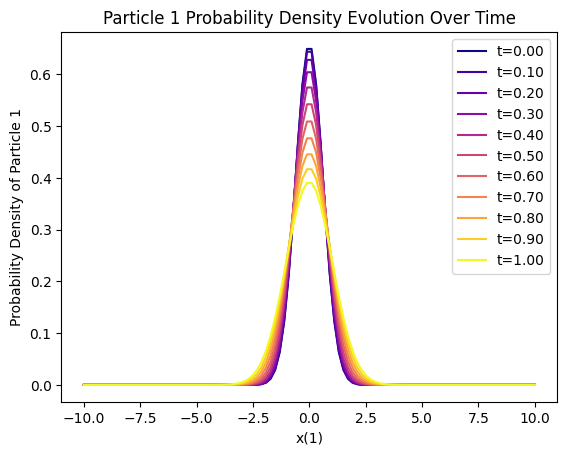

In [9]:
'''Visualization'''
'''For easier visualization, I've chosen to just plot the marginal probability of one of the particles, by integrating the total probability of Psi
over the axis of particles 2 and 3 (so, double integral over dx_2 and dx_3)
'''

def particle1_marginalprob(psi):
  #first, I calculate the total probability by squaring the absolute value of the wavefunction, for each entry in the array, which keeps it an array
  #Then, we use a sum of this probability over the axes of Particles 2 and 3 (so, summing over these axes of the array), and multiplying the dx_2dx_3 = dx^2
  total_probability = (np.abs(psi)**2)
  return np.sum(total_probability, axis=(1,2))*(dx**2)#/(np.sqrt(np.sum(np.abs(psi)**2)))


psi_list = get_all_psi(psi,dt)

#this determines how often the probability density is plotted-
#smaller period = higher frequency plotting
plotting_period = int(10)


#Plotting stuff
#This first bit just makes the plotted lines better colors
num_plots=len(range(0,len(psi_list), plotting_period))
colors=cm.plasma(np.linspace(0,1,num_plots))

#same plotting stuff here
for i, time_int in enumerate(range(0, len(psi_list), plotting_period)):
    psi_t= psi_list[time_int]
    particle1_density= particle1_marginalprob(psi_t)
    plt.plot(x, particle1_density,label=f"t={time_int*dt:.2f}",color=colors[i])

#plotting
plt.xlabel("x(1)")
plt.ylabel("Probability Density of Particle 1")
plt.title("Particle 1 Probability Density Evolution Over Time")
plt.legend()
plt.show()

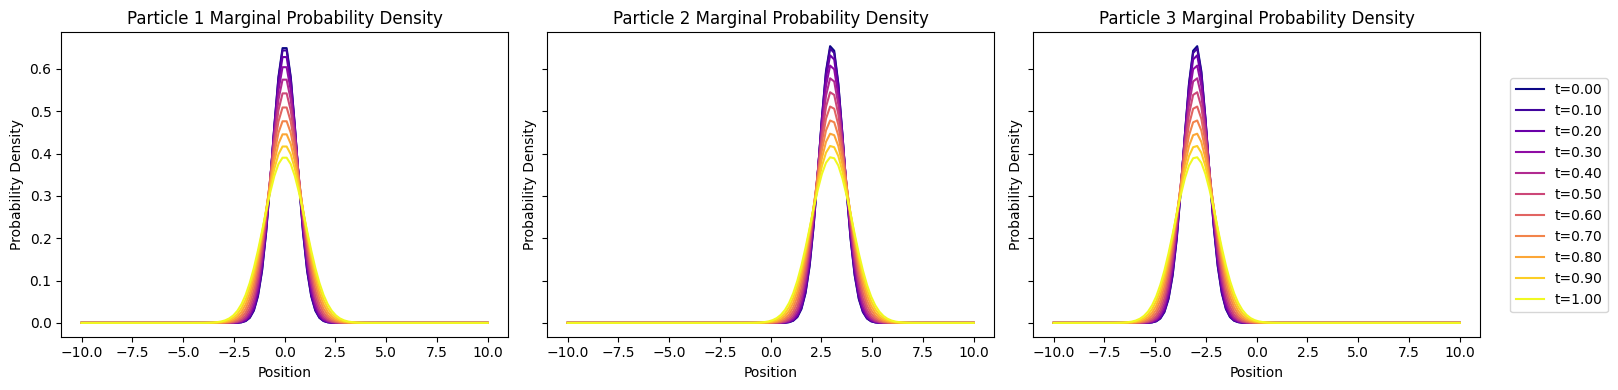

In [10]:
'''Simulation of wavefunction and particles by writing to disk
Also plots marginal probability of all three particles
'''
plotting_period= 10  # saves the plot once per period

#Runs simulation, writing to disk
#creates/overwrites psi_evolution file in write mode
with h5py.File('psi_evolution.h5', 'w') as f:
    #storing dt and dx in metadeta
    f.attrs['dt']= dt
    f.attrs['dx']= dx

    #saves a copy of the initial wavefunction
    psi_run =psi.copy()

    #evolving wavefunction and saving it
    for timestep in range(t + 1):
        if timestep % plotting_period == 0:
            f.create_dataset(f'psi_{timestep:05d}',data=psi_run,compression='gzip')
        psi_run = psi_next(psi_run,dt)


#opens saved wavefunctions as a read only file
with h5py.File('psi_evolution.h5', 'r') as f:
    dt_saved =f.attrs['dt']
    dx_saved= f.attrs['dx']

    saved_keys= sorted(f.keys()) #sorting saved wavefuction data in proper order
    num_plots= len(saved_keys)
    colors =cm.plasma(np.linspace(0,1,num_plots))

    #Creating marginal probability for each particle into lists
    p1_list, p2_list, p3_list =[],[],[]
    time_labels=[]

    for key in saved_keys:
        #loads each wavefunction individually to RAM, appends to desired lists
        psi_t = f[key][:]
        prob=np.abs(psi_t)**2
        p1_list.append(np.sum(prob,axis=(1,2))* dx_saved**2)  # integrates over x2, x3
        p2_list.append(np.sum(prob,axis=(0,2)) * dx_saved**2)  # integrates over x1, x3
        p3_list.append(np.sum(prob,axis=(0,1))* dx_saved**2)  # integrates over x1, x2
        time_labels.append(int(key.split('_')[1]))


#Plotting each marginal probability density
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
titles = ['Particle 1', 'Particle 2', 'Particle 3']
marginals = [p1_list, p2_list, p3_list]

for ax, densities, title in zip(axes, marginals, titles):
    for i, (density, timestep) in enumerate(zip(densities, time_labels)):
        ax.plot(x, density, label=f"t={timestep*dt_saved:.2f}", color=colors[i])
    ax.set_xlabel("Position")
    ax.set_ylabel("Probability Density")
    ax.set_title(f"{title} Marginal Probability Density")


#creates a single legend for every plot (probably not necessary if we know how the color gradient corresponds to time)
handles, labels=axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right',bbox_to_anchor=(1.08,0.5))
plt.tight_layout()
plt.show()